# Smart Traffic Sign Recognition System
Executed notebook with dataset analysis, perceptron training, predictions, and visualization.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 5)

data_path = Path("/mnt/data/DatasetCapstoneProject4.csv")
df = pd.read_csv(data_path)

print("Dataset Preview:\n")
print(df.head())

print("\nFull Dataset:\n")
print(df)

print("\nDataset Shape:", df.shape)
print("Columns:", list(df.columns))


Matplotlib is building the font cache; this may take a moment.


Dataset Preview:

   Sign_ID  Red_Color_Intensity  ...  Edge_Count  Stop_Sign
0        1                 0.90  ...           8          1
1        2                 0.20  ...           4          0
2        3                 0.85  ...           7          1
3        4                 0.30  ...           5          0
4        5                 0.88  ...           8          1

[5 rows x 6 columns]

Full Dataset:

   Sign_ID  Red_Color_Intensity  ...  Edge_Count  Stop_Sign
0        1                 0.90  ...           8          1
1        2                 0.20  ...           4          0
2        3                 0.85  ...           7          1
3        4                 0.30  ...           5          0
4        5                 0.88  ...           8          1
5        6                 0.25  ...           4          0
6        7                 0.92  ...           8          1
7        8                 0.35  ...           5          0
8        9                 0.86  ...        

## Separate features and target

In [2]:

X = df.drop(["Sign_ID", "Stop_Sign"], axis=1).values
y = df["Stop_Sign"].values

print("Features:\n", X)
print("\nTarget:\n", y)


Features:
 [[0.9  0.   1.   8.  ]
 [0.2  1.   0.   4.  ]
 [0.85 0.   1.   7.  ]
 [0.3  1.   0.   5.  ]
 [0.88 0.   1.   8.  ]
 [0.25 1.   0.   4.  ]
 [0.92 0.   1.   8.  ]
 [0.35 1.   0.   5.  ]
 [0.86 0.   1.   7.  ]
 [0.28 1.   0.   4.  ]]

Target:
 [1 0 1 0 1 0 1 0 1 0]


## Initialize perceptron parameters

In [3]:

weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 10

print("Initial Weights:", weights)
print("Initial Bias:", bias)
print("Learning Rate:", learning_rate)
print("Epochs:", epochs)


Initial Weights: [0. 0. 0. 0.]
Initial Bias: 0
Learning Rate: 0.1
Epochs: 10


## Activation function and training

In [4]:

def step_function(z):
    return 1 if z >= 0 else 0

history = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}")
    epoch_errors = 0
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)
        error = y[i] - y_pred

        weights = weights + learning_rate * error * X[i]
        bias = bias + learning_rate * error
        epoch_errors += abs(error)

        print(
            "Sample:", i,
            "Predicted:", y_pred,
            "Actual:", y[i],
            "Error:", error
        )
    history.append(epoch_errors)

print("\nTraining Completed.")
print("\nFinal Weights:", weights)
print("Final Bias:", bias)



Epoch 1
Sample: 0 Predicted: 1 Actual: 1 Error: 0
Sample: 1 Predicted: 1 Actual: 0 Error: -1
Sample: 2 Predicted: 0 Actual: 1 Error: 1
Sample: 3 Predicted: 1 Actual: 0 Error: -1
Sample: 4 Predicted: 0 Actual: 1 Error: 1
Sample: 5 Predicted: 1 Actual: 0 Error: -1
Sample: 6 Predicted: 1 Actual: 1 Error: 0
Sample: 7 Predicted: 1 Actual: 0 Error: -1
Sample: 8 Predicted: 0 Actual: 1 Error: 1
Sample: 9 Predicted: 1 Actual: 0 Error: -1

Epoch 2
Sample: 0 Predicted: 1 Actual: 1 Error: 0
Sample: 1 Predicted: 0 Actual: 0 Error: 0
Sample: 2 Predicted: 1 Actual: 1 Error: 0
Sample: 3 Predicted: 0 Actual: 0 Error: 0
Sample: 4 Predicted: 1 Actual: 1 Error: 0
Sample: 5 Predicted: 0 Actual: 0 Error: 0
Sample: 6 Predicted: 1 Actual: 1 Error: 0
Sample: 7 Predicted: 0 Actual: 0 Error: 0
Sample: 8 Predicted: 1 Actual: 1 Error: 0
Sample: 9 Predicted: 0 Actual: 0 Error: 0

Epoch 3
Sample: 0 Predicted: 1 Actual: 1 Error: 0
Sample: 1 Predicted: 0 Actual: 0 Error: 0
Sample: 2 Predicted: 1 Actual: 1 Error: 0
Sa

## Predictions and accuracy

In [5]:

predictions = []

for i in range(len(X)):
    linear_output = np.dot(X[i], weights) + bias
    y_pred = step_function(linear_output)
    predictions.append(y_pred)

predictions = np.array(predictions)
accuracy = np.mean(predictions == y)

print("Predictions:", predictions.tolist())
print("\nModel Accuracy:", accuracy)

results_df = df.copy()
results_df["Predicted_Stop_Sign"] = predictions
results_df["Correct"] = results_df["Stop_Sign"] == results_df["Predicted_Stop_Sign"]
results_df


Predictions: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

Model Accuracy: 1.0


,Sign_ID,Red_Color_Intensity,Circular_Shape,Text_Present,Edge_Count,Stop_Sign,Predicted_Stop_Sign,Correct
0,1,0.90,0,1,8,1,1,True
1,2,0.20,1,0,4,0,0,True
2,3,0.85,0,1,7,1,1,True
3,4,0.30,1,0,5,0,0,True
4,5,0.88,0,1,8,1,1,True
5,6,0.25,1,0,4,0,0,True
6,7,0.92,0,1,8,1,1,True
7,8,0.35,1,0,5,0,0,True
8,9,0.86,0,1,7,1,1,True
9,10,0.28,1,0,4,0,0,True


## Visualization

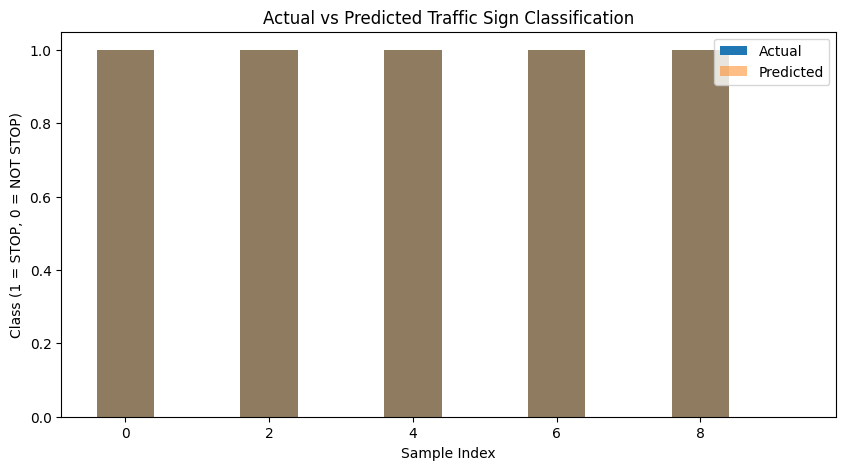

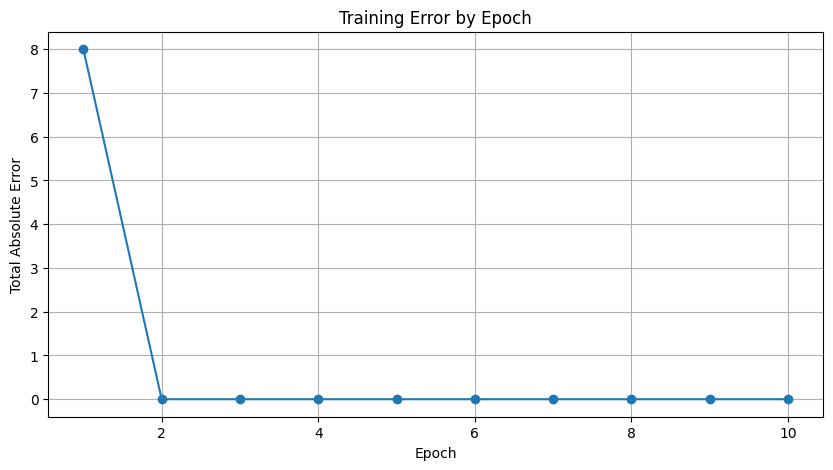

In [6]:

plt.figure()
plt.bar(range(len(y)), y, label="Actual")
plt.bar(range(len(predictions)), predictions, alpha=0.5, label="Predicted")
plt.title("Actual vs Predicted Traffic Sign Classification")
plt.xlabel("Sample Index")
plt.ylabel("Class (1 = STOP, 0 = NOT STOP)")
plt.legend()
plt.show()

plt.figure()
plt.plot(range(1, epochs+1), history, marker="o")
plt.title("Training Error by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Total Absolute Error")
plt.grid(True)
plt.show()


## Predict a new traffic sign

In [7]:

# [Red_Color_Intensity, Circular_Shape, Text_Present, Edge_Count]
new_sign = np.array([0.9, 0, 1, 8])

linear_output = np.dot(new_sign, weights) + bias
prediction = step_function(linear_output)

print("New Sign Features:", new_sign)
print("Linear Output:", linear_output)
if prediction == 1:
    print("Traffic Sign is STOP Sign.")
else:
    print("Traffic Sign is NOT STOP Sign.")


New Sign Features: [0.9 0.  1.  8. ]
Linear Output: 0.20890000000000092
Traffic Sign is STOP Sign.
